In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_ts = pd.read_csv("daily_total_sessions(lstm).csv")

df_ts.head()

,date,total_sessions,total_players,total_completed,completion_rate,average_deaths,average_time_spent
0,2025-01-01,2,2,1,50.00,14.50,550.00
1,2025-01-02,1,1,0,0.00,18.00,353.00
2,2025-01-04,6,5,0,0.00,14.17,522.17
3,2025-01-05,4,4,1,25.00,15.75,413.75
4,2025-01-06,3,3,1,33.33,13.67,432.33


In [2]:
df_ts.shape

(477, 7)

In [3]:
df_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 477 entries, 0 to 476
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                477 non-null    object 
 1   total_sessions      477 non-null    int64  
 2   total_players       477 non-null    int64  
 3   total_completed     477 non-null    int64  
 4   completion_rate     477 non-null    float64
 5   average_deaths      477 non-null    float64
 6   average_time_spent  477 non-null    float64
dtypes: float64(3), int64(3), object(1)
memory usage: 26.2+ KB


In [4]:
df_ts.isnull().sum()

,0
date,0
total_sessions,0
total_players,0
total_completed,0
completion_rate,0
average_deaths,0
average_time_spent,0


In [5]:
df_ts["date"] = pd.to_datetime(df_ts["date"])
df_ts = df_ts.sort_values("date").reset_index(drop=True)

df_ts.head()

,date,total_sessions,total_players,total_completed,completion_rate,average_deaths,average_time_spent
0,2025-01-01,2,2,1,50.00,14.50,550.00
1,2025-01-02,1,1,0,0.00,18.00,353.00
2,2025-01-04,6,5,0,0.00,14.17,522.17
3,2025-01-05,4,4,1,25.00,15.75,413.75
4,2025-01-06,3,3,1,33.33,13.67,432.33


In [6]:
print("Tanggal awal:", df_ts["date"].min())
print("Tanggal akhir:", df_ts["date"].max())
print("Jumlah hari:", len(df_ts))

Tanggal awal: 2025-01-01 00:00:00
Tanggal akhir: 2026-05-12 00:00:00
Jumlah hari: 477


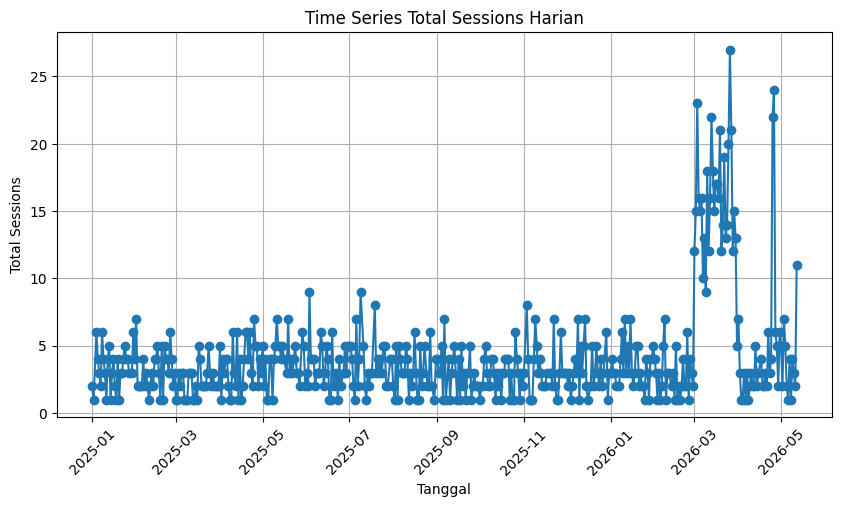

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(df_ts["date"], df_ts["total_sessions"], marker="o")
plt.title("Time Series Total Sessions Harian")
plt.xlabel("Tanggal")
plt.ylabel("Total Sessions")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [8]:
from sklearn.preprocessing import MinMaxScaler

# Ambil target prediksi
target_data = df_ts[["total_sessions"]].values

# Normalisasi data ke rentang 0-1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(target_data)

scaled_data[:5]

array([[0.03846154],
       [0.        ],
       [0.19230769],
       [0.11538462],
       [0.07692308]])

In [9]:
def create_sequences(data, look_back=3):
    X, y = [], []

    for i in range(len(data) - look_back):
        X.append(data[i:i + look_back])
        y.append(data[i + look_back])

    return np.array(X), np.array(y)

look_back = 3

X, y = create_sequences(scaled_data, look_back)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (474, 3, 1)
Shape y: (474, 1)


In [10]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (379, 3, 1)
X_test: (95, 3, 1)
y_train: (379, 1)
y_test: (95, 1)


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

tf.random.set_seed(42)

model = Sequential([
    LSTM(32, return_sequences=False, input_shape=(look_back, 1)),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=4,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0047 - val_loss: 0.0926
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0041 - val_loss: 0.0968
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0041 - val_loss: 0.0994
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0041 - val_loss: 0.1009
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0041 - val_loss: 0.1003
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0041 - val_loss: 0.1017
Epoch 7/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0040 - val_loss: 0.1025
Epoch 8/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0040 - val_loss: 0.1023
Epoch 9/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0040 - val_loss: 0.1027
Epoch 10/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0040 - val_loss: 0.1030
Epoch 11/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0040 - val_loss: 0.1034
Epoch 12/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0

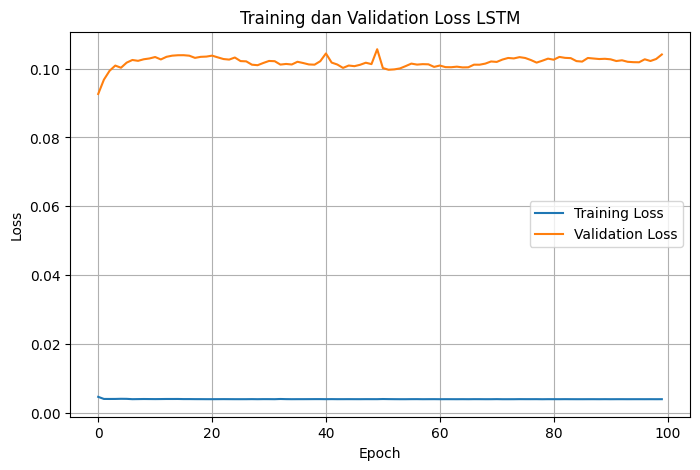

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training dan Validation Loss LSTM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Prediksi data test
y_pred_scaled = model.predict(X_test)

# Kembalikan hasil prediksi dan data aktual ke skala asli
y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test)

# Tampilkan beberapa hasil
comparison_df = pd.DataFrame({
    "actual_total_sessions": y_actual.flatten(),
    "predicted_total_sessions": y_pred.flatten()
})

comparison_df

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


,actual_total_sessions,predicted_total_sessions
0,1.0,3.188181
1,2.0,3.173144
2,5.0,3.174008
3,7.0,3.242302
4,1.0,3.218565
...,...,...
90,1.0,3.221162
91,4.0,3.160507
92,3.0,3.183609
93,2.0,3.189391


In [15]:
# Ambil tanggal target untuk setiap sequence
target_dates = df_ts["date"].iloc[look_back:].reset_index(drop=True)

# Ambil tanggal bagian test
test_dates = target_dates.iloc[train_size:].reset_index(drop=True)

comparison_df["date"] = test_dates
comparison_df = comparison_df[[
    "date",
    "actual_total_sessions",
    "predicted_total_sessions"
]]

comparison_df

,date,actual_total_sessions,predicted_total_sessions
0,2026-02-05,1.0,3.188181
1,2026-02-06,2.0,3.173144
2,2026-02-07,5.0,3.174008
3,2026-02-08,7.0,3.242302
4,2026-02-09,1.0,3.218565
...,...,...,...
90,2026-05-08,1.0,3.221162
91,2026-05-09,4.0,3.160507
92,2026-05-10,3.0,3.183609
93,2026-05-11,2.0,3.189391


In [17]:
comparison_df["predicted_total_sessions_rounded"] = (
    comparison_df["predicted_total_sessions"]
    .round()
    .astype(int)
)

comparison_df

/tmp/ipykernel_11420/1615479730.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comparison_df["predicted_total_sessions_rounded"] = (


,date,actual_total_sessions,predicted_total_sessions,predicted_total_sessions_rounded
0,2026-02-05,1.0,3.188181,3
1,2026-02-06,2.0,3.173144,3
2,2026-02-07,5.0,3.174008,3
3,2026-02-08,7.0,3.242302,3
4,2026-02-09,1.0,3.218565,3
...,...,...,...,...
90,2026-05-08,1.0,3.221162,3
91,2026-05-09,4.0,3.160507,3
92,2026-05-10,3.0,3.183609,3
93,2026-05-11,2.0,3.189391,3


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

# MAPE aman dari pembagian nol
mape = np.mean(
    np.abs((y_actual - y_pred) / np.where(y_actual == 0, 1, y_actual))
) * 100

print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("MAPE:", round(mape, 2), "%")

MAE: 5.5989
RMSE: 8.3894
MAPE: 75.0 %


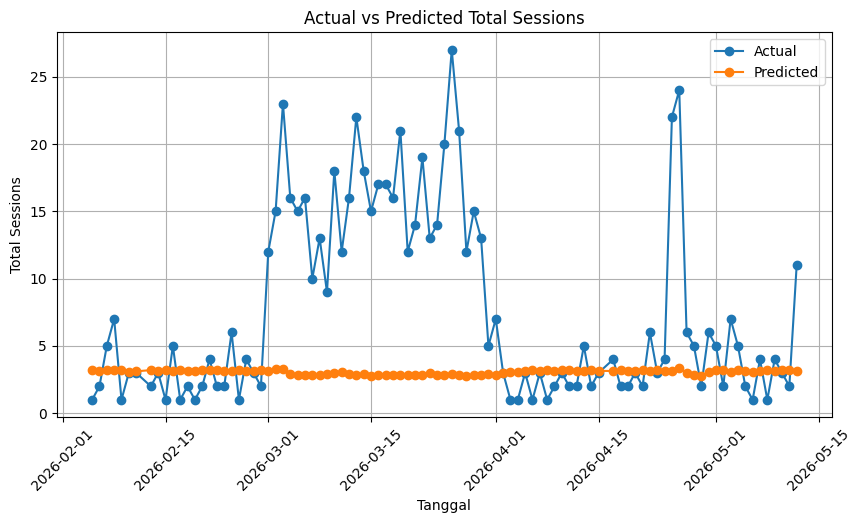

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    comparison_df["date"],
    comparison_df["actual_total_sessions"],
    marker="o",
    label="Actual"
)

plt.plot(
    comparison_df["date"],
    comparison_df["predicted_total_sessions"],
    marker="o",
    label="Predicted"
)

plt.title("Actual vs Predicted Total Sessions")
plt.xlabel("Tanggal")
plt.ylabel("Total Sessions")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

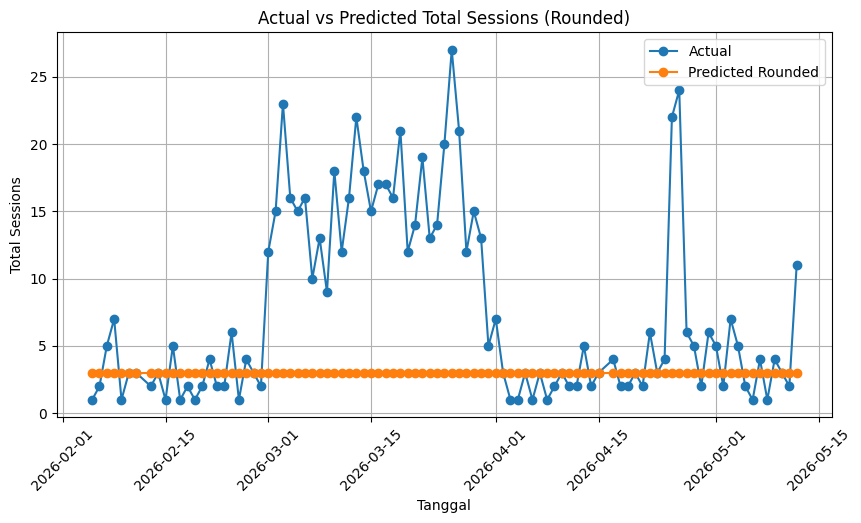

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(
    comparison_df["date"],
    comparison_df["actual_total_sessions"],
    marker="o",
    label="Actual"
)

plt.plot(
    comparison_df["date"],
    comparison_df["predicted_total_sessions_rounded"],
    marker="o",
    label="Predicted Rounded"
)

plt.title("Actual vs Predicted Total Sessions (Rounded)")
plt.xlabel("Tanggal")
plt.ylabel("Total Sessions")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [21]:
forecast_result = comparison_df.copy()

forecast_result["actual_total_sessions"] = forecast_result[
    "actual_total_sessions"
].round(2)

forecast_result["predicted_total_sessions"] = forecast_result[
    "predicted_total_sessions"
].round(2)

forecast_result.to_csv("hasil_lstm_forecasting_total_sessions.csv", index=False)

forecast_result

,date,actual_total_sessions,predicted_total_sessions,predicted_total_sessions_rounded
0,2026-02-05,1.0,3.19,3
1,2026-02-06,2.0,3.17,3
2,2026-02-07,5.0,3.17,3
3,2026-02-08,7.0,3.24,3
4,2026-02-09,1.0,3.22,3
...,...,...,...,...
90,2026-05-08,1.0,3.22,3
91,2026-05-09,4.0,3.16,3
92,2026-05-10,3.0,3.18,3
93,2026-05-11,2.0,3.19,3
